# 02 Modelltraining

Dieses Notebook trainiert die vier finalen Klassifikationsmodelle für das Dry-Bean-Projekt. Bewertet werden Accuracy, Macro-F1, klassenweise Kennzahlen und Konfusionsmatrizen. Die Parameter stammen aus den vorherigen Versuchen und bleiben hier fest, damit der Ablauf für die Abgabe reproduzierbar ist.


## Vorbereitung

Benötigte Bibliotheken werden geladen. Die Zertifikate für den Abruf des UCI-Datensatzes werden eingerichtet. Der Zufallswert wird für reproduzierbare Ergebnisse festgelegt.

In [1]:
import os
import ssl
import warnings

import certifi

# Nutzt das certifi-Zertifikat, falls Python den Zertifikatsspeicher des Systems nicht findet.
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42



## Daten laden und Feature-Auswahl

Der Datensatz wird über `ucimlrepo` aus dem UCI Machine Learning Repository geladen. Verwendet wird der finale Feature-Satz aus der EDA.


In [2]:
dry_bean = fetch_ucirepo(id=602)
X_all = dry_bean.data.features
y = dry_bean.data.targets.squeeze()

expected_classes = {"SEKER", "BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SIRA"}
assert X_all.shape == (13611, 16), f"Unexpected feature shape: {X_all.shape}"
assert y.shape[0] == 13611, f"Unexpected target length: {y.shape[0]}"
assert set(y.unique()) == expected_classes, f"Unexpected classes: {sorted(y.unique())}"
assert X_all.isna().sum().sum() == 0, "Unexpected missing values in features"
assert y.isna().sum() == 0, "Unexpected missing values in target"

selected_features = [
    "Area",
    "AspectRatio",
    "Eccentricity",
    "Compactness",
    "Roundness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]
X = X_all[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)
print("Klassen:", sorted(y.unique()))


Trainingsdaten: (10888, 8)
Testdaten: (2723, 8)
Klassen: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## Finale Modelle

Logistische Regression und MLP arbeiten mit standardisierten Eingaben. Die beiden Baumverfahren erhalten die Merkmale unverändert. Die festen Parameter stammen aus den vorherigen Versuchen.


In [3]:
models = {
    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            activation="tanh",
            alpha=0.04,
            early_stopping=False,
            hidden_layer_sizes=(60, 60),
            learning_rate="constant",
            solver="adam",
            max_iter=300,
            random_state=RANDOM_STATE,
            n_iter_no_change=5,
        )),
    ]),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        min_samples_leaf=2,
        max_leaf_nodes=31,
        max_iter=300,
        max_depth=5,
        learning_rate=0.1,
        l2_regularization=0.0,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=100,
            class_weight=None,
            max_iter=5000,
            l1_ratio=1.0,
            solver="saga",
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=25,
        class_weight=None,
        max_depth=None,
        max_features="log2",
        min_samples_leaf=2,
        min_samples_split=5,
        random_state=RANDOM_STATE,
    ),
}


## Modelltraining und Kennzahlen

Alle vier Modelle werden auf den Trainingsdaten trainiert und auf den Testdaten mit Accuracy und Macro-F1 bewertet.


In [4]:
results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,macro_f1
0,MLP Neural Network,0.923246,0.934268
1,HistGradientBoosting,0.920308,0.931808
2,Random Forest,0.918472,0.931165
3,Logistic Regression,0.917371,0.930699


## Klassenweise Kennzahlen

Die Reports zeigen Precision, Recall und F1-Score für jede Bohnensorte.


In [5]:
for model_name in results_df["model"]:
    print(model_name)
    print(classification_report(y_test, predictions[model_name]))


MLP Neural Network
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.90      0.93      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.95      0.96      0.96       406
        SIRA       0.88      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

HistGradientBoosting
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.93      0.93      0.93       326
    DERMASON       0.90      0.93      0.91       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.96     

## Konfusionsmatrizen

Die Konfusionsmatrizen zeigen, welche Bohnensorten die Modelle besonders häufig verwechseln.


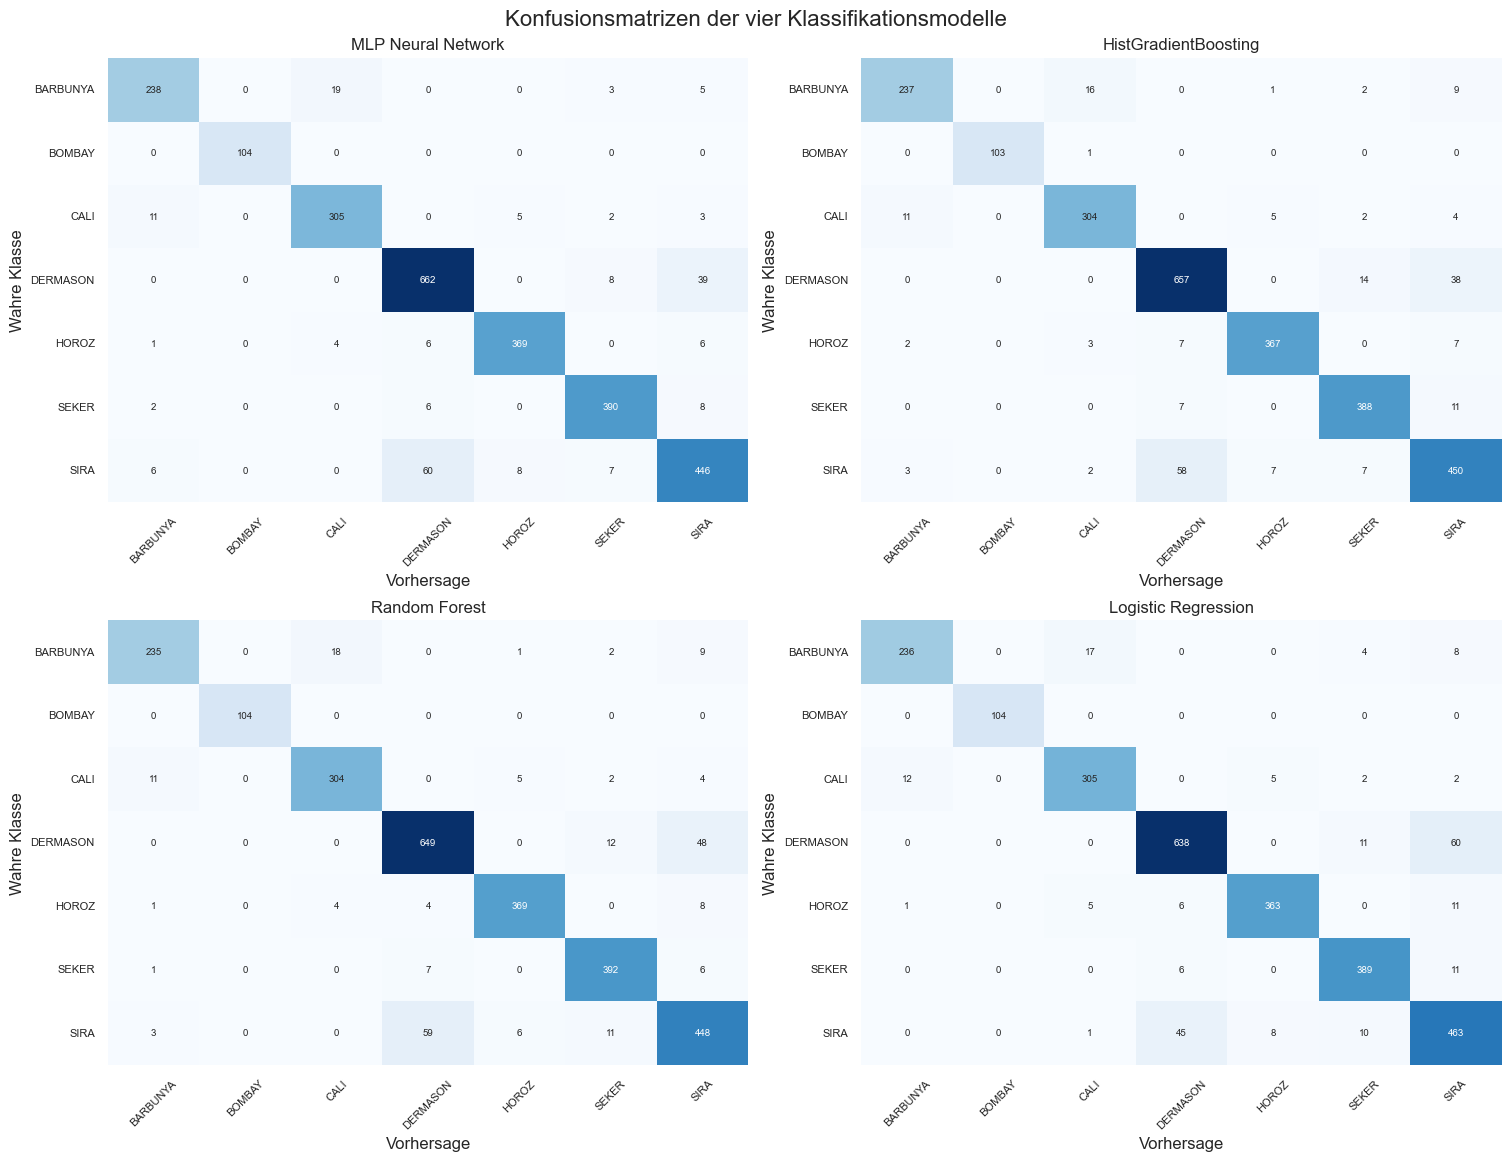

In [6]:
labels = sorted(y.unique())
fig, axes = plt.subplots(2, 2, figsize=(15, 11.5), constrained_layout=True)
axes = axes.ravel()

for ax, model_name in zip(axes, results_df["model"]):
    cm = confusion_matrix(y_test, predictions[model_name], labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        annot_kws={"size": 7},
    )
    ax.set_title(model_name)
    ax.set_xlabel("Vorhersage")
    ax.set_ylabel("Wahre Klasse")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)

fig.suptitle("Konfusionsmatrizen der vier Klassifikationsmodelle", fontsize=16)

plt.show()
